<a href="https://colab.research.google.com/github/annetken/Monte-Carlo-Methods-for-Option-Pricing/blob/main/Monte_Carlo_Methods_for_Option_Pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exercise 1**
1a) Implement the plain MC using exact GBM simulation


In [15]:
import numpy as np

np.random.seed(42)

# Given parameters
S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1

# Number of simulations
M = 1000

# Step 1: Generate random standard normal variables
Z = np.random.normal(0, 1, M)

# Step 2: Exact GBM formula
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

# Step 3: Display first 10 simulated future prices
print(ST[:10])

[113.8080226  100.23498965 117.29684912 139.73896651  98.33101696
  98.33133983 141.31801116 120.1399282   93.81036104 114.85634743]


1b) Price call and put for different M

In [16]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Given parameters
S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1

# Simulation sizes required by the question
M_values = [10**3, 10**4, 10**5, 10**6]

results = []

for M in M_values:

    # Step 1: Generate random shocks
    Z = np.random.normal(0, 1, M)

    # Step 2: Simulate terminal stock price using exact GBM
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    # Step 3: Calculate call and put payoffs
    call_payoff = np.maximum(ST - K, 0)
    put_payoff = np.maximum(K - ST, 0)

    # Step 4: Discount average payoff to today
    discount = np.exp(-r * T)

    call_price = discount * np.mean(call_payoff)
    put_price = discount * np.mean(put_payoff)

    # Step 5: Calculate standard errors
    call_se = discount * np.std(call_payoff, ddof=1) / np.sqrt(M)
    put_se = discount * np.std(put_payoff, ddof=1) / np.sqrt(M)

    # Store results
    results.append([M, call_price, call_se, put_price, put_se])

# Put results in a table
df_ex1_q2 = pd.DataFrame(results, columns=[
    "M",
    "Call Estimate",
    "Call Standard Error",
    "Put Estimate",
    "Put Standard Error"
])

df_ex1_q2

,M,Call Estimate,Call Standard Error,Put Estimate,Put Standard Error
0,1000,10.516569,0.472961,5.321528,0.259992
1,10000,10.363477,0.146700,5.638469,0.087300
2,100000,10.489162,0.046585,5.559565,0.027353
3,1000000,10.439130,0.014709,5.592775,0.008673


1c) Verfify put-call parity
Since the last column indicates the output as 'true' then the simulation passes the put-call parity test

In [17]:
# Exercise 1 Question 3: Verify Put-Call Parity

# Step 1: Theoretical parity value
parity_theory = S0 - K * np.exp(-r * T)

# Step 2: Empty list for results
parity_results = []

# Step 3: Use results from Question 2
for i in range(len(df_ex1_q2)):

    M = df_ex1_q2.loc[i, "M"]

    call_price = df_ex1_q2.loc[i, "Call Estimate"]
    put_price = df_ex1_q2.loc[i, "Put Estimate"]

    call_se = df_ex1_q2.loc[i, "Call Standard Error"]
    put_se = df_ex1_q2.loc[i, "Put Standard Error"]

    # Step 4: Parity difference
    parity_difference = abs(call_price - put_price - parity_theory)

    # Step 5: Combined standard error
    combined_se = np.sqrt(call_se**2 + put_se**2)
    two_se = 2 * combined_se

    # Step 6: Check condition
    parity_holds = parity_difference < two_se

    # Step 7: Store results
    parity_results.append([
        M,
        call_price,
        put_price,
        parity_difference,
        two_se,
        parity_holds
    ])

# Step 8: Create final table
df_ex1_q3 = pd.DataFrame(parity_results, columns=[
    "M",
    "Call Estimate",
    "Put Estimate",
    "Parity Difference",
    "2SE",
    "Parity Holds?"
])

df_ex1_q3

,M,Call Estimate,Put Estimate,Parity Difference,2SE,Parity Holds?
0,1000,10.516569,5.321528,0.317984,1.079422,True
1,10000,10.363477,5.638469,0.152050,0.341422,True
2,100000,10.489162,5.559565,0.052539,0.108044,True
3,1000000,10.439130,5.592775,0.030703,0.034151,True


1d) Comment on the convergence rate. As M increases, what happens to the estimates and standard errors?

In [18]:
# Creating a convergence table

df_ex1_q4 = df_ex1_q2.copy()

# Add theoretical Monte Carlo convergence rate
df_ex1_q4["1/sqrt(M)"] = 1 / np.sqrt(df_ex1_q4["M"])

df_ex1_q4

,M,Call Estimate,Call Standard Error,Put Estimate,Put Standard Error,1/sqrt(M)
0,1000,10.516569,0.472961,5.321528,0.259992,0.031623
1,10000,10.363477,0.146700,5.638469,0.087300,0.010000
2,100000,10.489162,0.046585,5.559565,0.027353,0.003162
3,1000000,10.439130,0.014709,5.592775,0.008673,0.001000


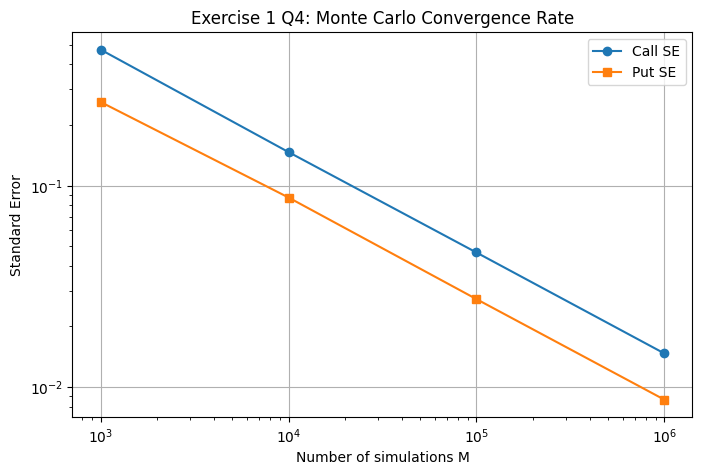

In [19]:
# Plotting standard error against numer of simulations

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    df_ex1_q4["M"],
    df_ex1_q4["Call Standard Error"],
    marker="o",
    label="Call SE"
)

plt.plot(
    df_ex1_q4["M"],
    df_ex1_q4["Put Standard Error"],
    marker="s",
    label="Put SE"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of simulations M")
plt.ylabel("Standard Error")
plt.title("Exercise 1 Q4: Monte Carlo Convergence Rate")
plt.legend()
plt.grid(True)

plt.show()

Exercise 2. 2a) Verify  SE ∝ 1/
√
M


In [20]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
# Defining the inputs
S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1

In [21]:
# The Euler's pricing function
def euler_call_price(S0, K, r, sigma, T, M, m):

    # Step size
    dt = T / m

    # Start all simulations at today's price S0
    S = np.full(M, S0)

    # Simulate the stock price step by step
    for step in range(m):

        # Generate random shocks
        Z = np.random.normal(0, 1, M)

        # Euler update formula
        S = S + r * S * dt + sigma * S * np.sqrt(dt) * Z

    # European call payoff at maturity
    payoff = np.maximum(S - K, 0)

    # Discount payoff back to today
    discount = np.exp(-r * T)

    # Monte Carlo price estimate
    price = discount * np.mean(payoff)

    # Standard error
    se = discount * np.std(payoff, ddof=1) / np.sqrt(M)

    return price, se

In [22]:
# Running for the different values of M
np.random.seed(42)

m_fixed = 100

M_values_ex2 = [10**2, 10**3, 10**4, 10**5]

results_ex2_q1 = []

for M in M_values_ex2:

    price, se = euler_call_price(S0, K, r, sigma, T, M, m_fixed)

    results_ex2_q1.append([
        M,
        m_fixed,
        price,
        se,
        1 / np.sqrt(M)
    ])

In [23]:
# Creating the results table
df_ex2_q1 = pd.DataFrame(results_ex2_q1, columns=[
    "M",
    "m",
    "Vhat Estimate",
    "Standard Error",
    "1/sqrt(M)"
])

df_ex2_q1

,M,m,Vhat Estimate,Standard Error,1/sqrt(M)
0,100,100,9.416949,1.397485,0.100000
1,1000,100,10.837755,0.465401,0.031623
2,10000,100,10.205253,0.144635,0.010000
3,100000,100,10.399478,0.046204,0.003162


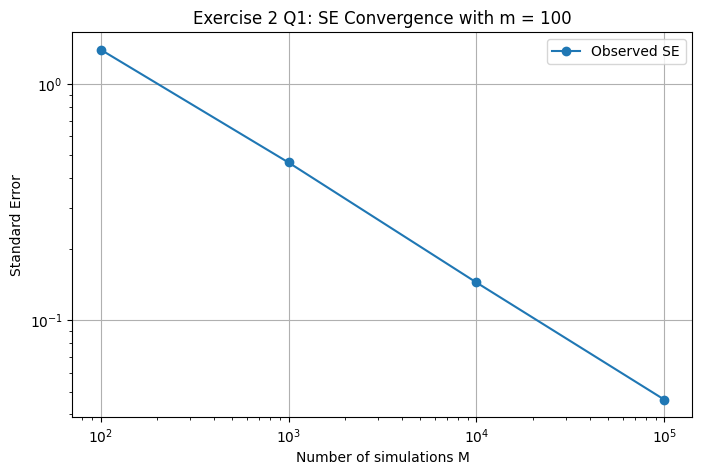

In [24]:
# Plotting standard error against M
plt.figure(figsize=(8,5))

plt.plot(
    df_ex2_q1["M"],
    df_ex2_q1["Standard Error"],
    marker="o",
    label="Observed SE"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of simulations M")
plt.ylabel("Standard Error")
plt.title("Exercise 2 Q1: SE Convergence with m = 100")

plt.legend()
plt.grid(True)

plt.show()

2b) Is there systematic bias as m changes?

In [25]:
# fixing M= 10^5
M_fixed = 10**5

In [26]:
# defining different time steps
m_values = [10, 50, 100, 500, 1000]

In [27]:
# Running Euler simulation for each m
np.random.seed(42)

results_ex2_q2 = []

for m in m_values:

    price, se = euler_call_price(S0, K, r, sigma, T, M_fixed, m)

    results_ex2_q2.append([
        M_fixed,
        m,
        price,
        se
    ])

In [28]:
# Creating a table
df_ex2_q2 = pd.DataFrame(results_ex2_q2, columns=[
    "M",
    "m",
    "Vhat Estimate",
    "Standard Error"
])

df_ex2_q2

,M,m,Vhat Estimate,Standard Error
0,100000,10,10.369419,0.045707
1,100000,50,10.418506,0.046271
2,100000,100,10.491781,0.046498
3,100000,500,10.337364,0.046394
4,100000,1000,10.506844,0.046766


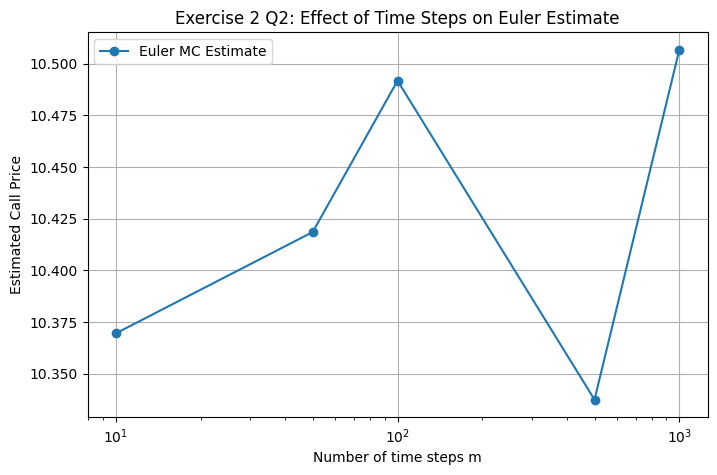

In [29]:
# Plotting estimates against m
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    df_ex2_q2["m"],
    df_ex2_q2["Vhat Estimate"],
    marker="o",
    label="Euler MC Estimate"
)

plt.xscale("log")

plt.xlabel("Number of time steps m")
plt.ylabel("Estimated Call Price")
plt.title("Exercise 2 Q2: Effect of Time Steps on Euler Estimate")

plt.legend()
plt.grid(True)

plt.show()

2c) Create a convergence table showing the error  |VˆM − VBS


In [30]:
# computing the Black-sholes Call price
from scipy.stats import norm
import numpy as np
import pandas as pd

def black_scholes_call(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    call_price = S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

    return call_price

VBS = black_scholes_call(S0, K, r, sigma, T)

print("Black-Scholes Call Price:", VBS)

Black-Scholes Call Price: 10.450583572185565


In [31]:
# Defining values of M and m
M_values_q3 = [10**2, 10**3, 10**4, 10**5]
m_values_q3 = [10, 50, 100, 500, 1000]

In [32]:
# Creating the table and filling it with errors
error_table = pd.DataFrame(index=M_values_q3, columns=m_values_q3)
np.random.seed(42)

for M in M_values_q3:
    for m in m_values_q3:

        price, se = euler_call_price(S0, K, r, sigma, T, M, m)

        error = abs(price - VBS)

        error_table.loc[M, m] = error


In [33]:
# Displaying the error table
error_table

,10,50,100,500,1000
100,0.423777,0.671372,0.545812,0.56257,0.50832
1000,0.199605,0.262454,0.10984,0.346264,0.802569
10000,0.103271,0.395352,0.193543,0.042357,0.09228
100000,0.004384,0.039894,0.076554,0.098562,0.056405


2d)  Determine the optimal (M∗
, m
∗
) allocation

In [34]:
C = 10**7

# Optimal number of time steps for Euler
m_star = C ** (1/3)

# Optimal number of simulations
M_star = C / m_star

print("Optimal time steps m* =", round(m_star))
print("Optimal simulations M* =", round(M_star))
print("Budget check M* x m* =", round(M_star) * round(m_star))

Optimal time steps m* = 215
Optimal simulations M* = 46416
Budget check M* x m* = 9979440


Exercise 3: 3a) Computing the analytical Black Sholes price

In [35]:
import numpy as np
from scipy.stats import norm

# Given parameters
S0 = 5
K = 5
r = 0.06
sigma = 0.30
T = 1

# Compute d2
d2 = (np.log(S0/K) + (r - 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

# Analytical digital call price
Vdig = np.exp(-r*T) * norm.cdf(d2)

print("d2 =", d2)
print("Analytical Digital Call Price =", Vdig)

d2 = 0.05
Analytical Digital Call Price = 0.48965992697272614


3b)

In [36]:
# Defining inputs
import numpy as np
import pandas as pd

np.random.seed(42)

S0 = 5
K = 5
r = 0.06
sigma = 0.30
T = 1

M_values = [10**3, 10**4, 10**5, 10**6]

Simulate S
T
	​

 using exact GBM

In [37]:
def exact_gbm_price(S0, r, sigma, T, M):
    Z = np.random.normal(0, 1, M)
    ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    return ST

In [38]:
# Pricing the digital call
results_ex3_q2 = []

for M in M_values:

    # Simulate terminal prices
    ST = exact_gbm_price(S0, r, sigma, T, M)

    # Digital payoff: 1 if ST > K, otherwise 0
    payoff = (ST > K).astype(float)

    # Discount average payoff
    discount = np.exp(-r*T)

    price = discount * np.mean(payoff)

    # Standard error
    se = discount * np.std(payoff, ddof=1) / np.sqrt(M)

    results_ex3_q2.append([M, price, se])

In [39]:
# The table displaying the results
df_ex3_q2 = pd.DataFrame(results_ex3_q2, columns=[
    "M",
    "Digital Call Estimate",
    "Standard Error"
])

df_ex3_q2

,M,Digital Call Estimate,Standard Error
0,1000,0.501960,0.014866
1,10000,0.486233,0.004707
2,100000,0.491036,0.001488
3,1000000,0.489227,0.000471


3c) Comparing convergence with that of Vanilla Call

In [40]:
# The code for Vanilla Call Monte Carlo
results_vanilla = []

for M in M_values:

    # Simulate terminal prices using exact GBM
    ST = exact_gbm_price(S0, r, sigma, T, M)

    # Vanilla call payoff
    payoff = np.maximum(ST - K, 0)

    # Discount average payoff
    discount = np.exp(-r*T)

    price = discount * np.mean(payoff)

    # Standard error
    se = discount * np.std(payoff, ddof=1) / np.sqrt(M)

    results_vanilla.append([M, price, se])

In [41]:
# Vanilla Call Table
df_vanilla = pd.DataFrame(results_vanilla, columns=[
    "M",
    "Vanilla Call Estimate",
    "Vanilla Call SE"
])

df_vanilla

,M,Vanilla Call Estimate,Vanilla Call SE
0,1000,0.723543,0.037223
1,10000,0.736424,0.011459
2,100000,0.739065,0.003613
3,1000000,0.735939,0.001142


In [42]:
# Comparing digital and Vanilla Results
df_ex3_q3 = pd.merge(df_ex3_q2, df_vanilla, on="M")

df_ex3_q3

,M,Digital Call Estimate,Standard Error,Vanilla Call Estimate,Vanilla Call SE
0,1000,0.501960,0.014866,0.723543,0.037223
1,10000,0.486233,0.004707,0.736424,0.011459
2,100000,0.491036,0.001488,0.739065,0.003613
3,1000000,0.489227,0.000471,0.735939,0.001142


In [43]:
# Comparing the Standard errors
df_ex3_q3["Which SE is Larger?"] = np.where(
    df_ex3_q3["Standard Error"] > df_ex3_q3["Vanilla Call SE"],
    "Digital Call",
    "Vanilla Call"
)

df_ex3_q3

,M,Digital Call Estimate,Standard Error,Vanilla Call Estimate,Vanilla Call SE,Which SE is Larger?
0,1000,0.501960,0.014866,0.723543,0.037223,Vanilla Call
1,10000,0.486233,0.004707,0.736424,0.011459,Vanilla Call
2,100000,0.491036,0.001488,0.739065,0.003613,Vanilla Call
3,1000000,0.489227,0.000471,0.735939,0.001142,Vanilla Call


3d) Plotting both convergence curves on the same axes, including 95% confidence bands

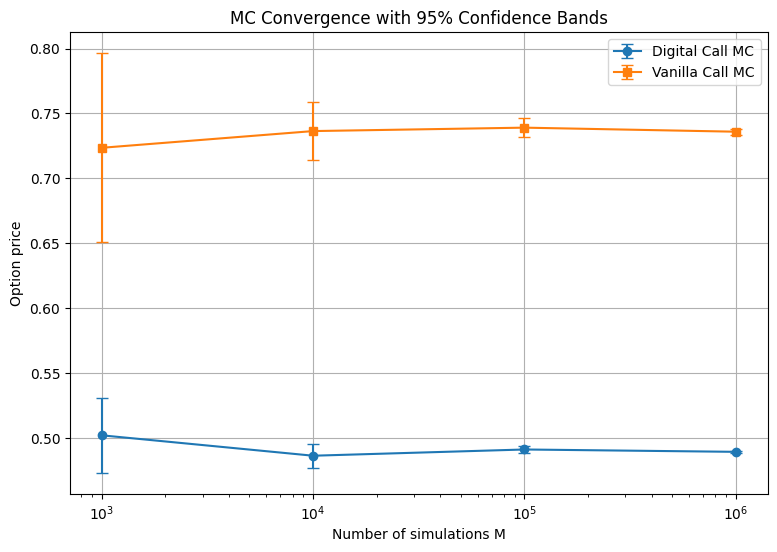

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

# Digital call convergence with 95% confidence band
plt.errorbar(
    df_ex3_q3["M"],
    df_ex3_q3["Digital Call Estimate"],
    yerr=1.96 * df_ex3_q3["Standard Error"],
    marker="o",
    capsize=4,
    label="Digital Call MC"
)

# Vanilla call convergence with 95% confidence band
plt.errorbar(
    df_ex3_q3["M"],
    df_ex3_q3["Vanilla Call Estimate"],
    yerr=1.96 * df_ex3_q3["Vanilla Call SE"],
    marker="s",
    capsize=4,
    label="Vanilla Call MC"
)

plt.xscale("log")

plt.xlabel("Number of simulations M")
plt.ylabel("Option price")
plt.title("MC Convergence with 95% Confidence Bands")
plt.legend()
plt.grid(True)

plt.show()

         M  Call Estimate  Call Standard Error  Put Estimate  \
0     1000      10.516569             0.472961      5.321528   
1    10000      10.363477             0.146700      5.638469   
2   100000      10.489162             0.046585      5.559565   
3  1000000      10.439130             0.014709      5.592775   

   Put Standard Error  1/sqrt(M)  
0            0.259992   0.031623  
1            0.087300   0.010000  
2            0.027353   0.003162  
3            0.008673   0.001000  


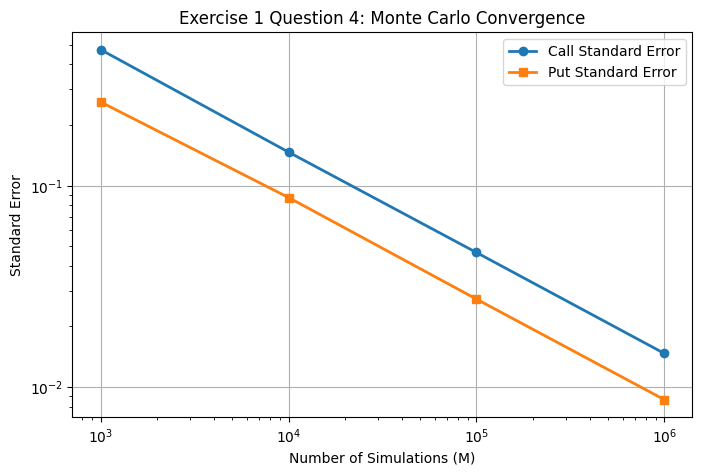

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:

# Exercise 1 Question 4
# Monte Carlo Convergence Plot


import numpy as np
import matplotlib.pyplot as plt

# Create a copy of the Question 2 results
df_ex1_q4 = df_ex1_q2.copy()

# Compute theoretical convergence rate
df_ex1_q4["1/sqrt(M)"] = 1 / np.sqrt(df_ex1_q4["M"])

# Display the table
print(df_ex1_q4)

# ------------------------------------------------------------
# Plot Standard Error Convergence
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    df_ex1_q4["M"],
    df_ex1_q4["Call Standard Error"],
    marker="o",
    linewidth=2,
    label="Call Standard Error"
)

plt.plot(
    df_ex1_q4["M"],
    df_ex1_q4["Put Standard Error"],
    marker="s",
    linewidth=2,
    label="Put Standard Error"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of Simulations (M)")
plt.ylabel("Standard Error")
plt.title("Exercise 1 Question 4: Monte Carlo Convergence")
plt.grid(True)
plt.legend()

# Save graph
plt.savefig(
    "Exercise1_Convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Download graph (Google Colab only)
# ------------------------------------------------------------

try:
    from google.colab import files
    files.download("Exercise1_Convergence.png")
except:
    print("Graph saved successfully as 'Exercise1_Convergence.png'")

        M    m  Vhat Estimate  Standard Error  1/sqrt(M)
0     100  100       0.661197        0.106195   0.100000
1    1000  100       0.765880        0.035878   0.031623
2   10000  100       0.716588        0.011176   0.010000
3  100000  100       0.731706        0.003573   0.003162


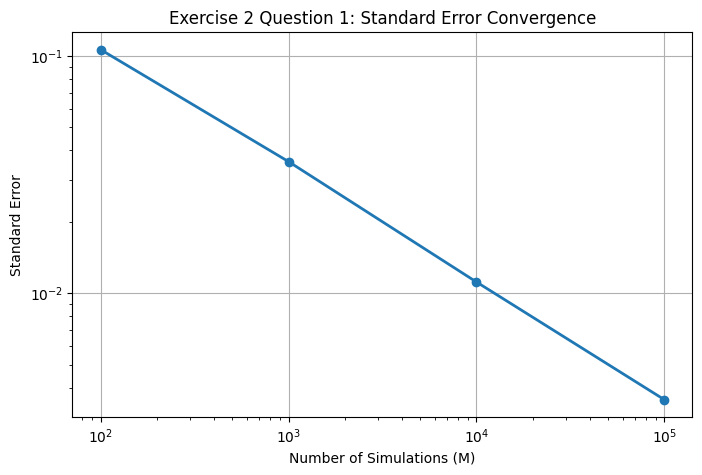

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
# Exercise 2 Question 1
# Convergence of Standard Error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Recreate the results table if necessary
np.random.seed(42)

M_values = [10**2, 10**3, 10**4, 10**5]
m_fixed = 100

results_ex2_q1 = []

for M in M_values:

    price, se = euler_call_price(
        S0,
        K,
        r,
        sigma,
        T,
        M,
        m_fixed
    )

    results_ex2_q1.append([
        M,
        m_fixed,
        price,
        se,
        1/np.sqrt(M)
    ])

df_ex2_q1 = pd.DataFrame(
    results_ex2_q1,
    columns=[
        "M",
        "m",
        "Vhat Estimate",
        "Standard Error",
        "1/sqrt(M)"
    ]
)

print(df_ex2_q1)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    df_ex2_q1["M"],
    df_ex2_q1["Standard Error"],
    marker="o",
    linewidth=2
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of Simulations (M)")
plt.ylabel("Standard Error")
plt.title("Exercise 2 Question 1: Standard Error Convergence")

plt.grid(True)

plt.savefig(
    "Exercise2_Q1_Convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

try:
    from google.colab import files
    files.download("Exercise2_Q1_Convergence.png")
except:
    print("Graph saved successfully.")

        M     m  Vhat Estimate  Standard Error
0  100000    10       0.730755        0.003517
1  100000    50       0.733492        0.003579
2  100000   100       0.738919        0.003601
3  100000   500       0.727811        0.003591
4  100000  1000       0.740306        0.003627


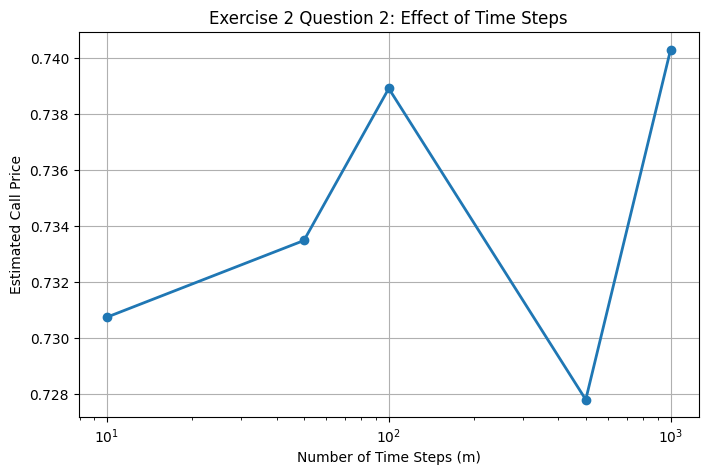

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
# Exercise 2 Question 2
# Euler Bias Plot

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

np.random.seed(42)

M_fixed = 10**5

m_values = [10, 50, 100, 500, 1000]

results_ex2_q2 = []

for m in m_values:

    price, se = euler_call_price(
        S0,
        K,
        r,
        sigma,
        T,
        M_fixed,
        m
    )

    results_ex2_q2.append([
        M_fixed,
        m,
        price,
        se
    ])

df_ex2_q2 = pd.DataFrame(
    results_ex2_q2,
    columns=[
        "M",
        "m",
        "Vhat Estimate",
        "Standard Error"
    ]
)

print(df_ex2_q2)

plt.figure(figsize=(8,5))

plt.plot(
    df_ex2_q2["m"],
    df_ex2_q2["Vhat Estimate"],
    marker="o",
    linewidth=2
)

plt.xscale("log")

plt.xlabel("Number of Time Steps (m)")
plt.ylabel("Estimated Call Price")

plt.title("Exercise 2 Question 2: Effect of Time Steps")

plt.grid(True)

plt.savefig(
    "Exercise2_Q2_Bias.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

try:
    from google.colab import files
    files.download("Exercise2_Q2_Bias.png")
except:
    print("Graph saved successfully.")

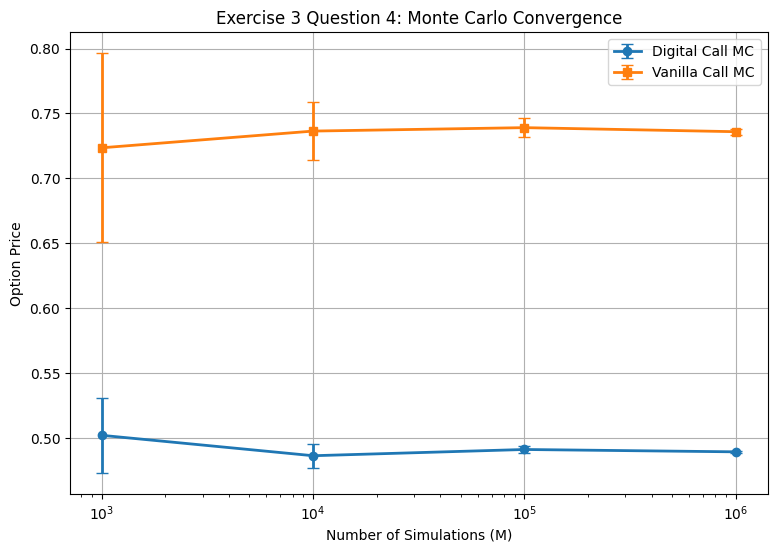

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
# Exercise 3 Question 4
# Digital vs Vanilla Convergence

import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.errorbar(
    df_ex3_q3["M"],
    df_ex3_q3["Digital Call Estimate"],
    yerr=1.96*df_ex3_q3["Standard Error"],
    marker="o",
    capsize=4,
    linewidth=2,
    label="Digital Call MC"
)

plt.errorbar(
    df_ex3_q3["M"],
    df_ex3_q3["Vanilla Call Estimate"],
    yerr=1.96*df_ex3_q3["Vanilla Call SE"],
    marker="s",
    capsize=4,
    linewidth=2,
    label="Vanilla Call MC"
)

plt.xscale("log")

plt.xlabel("Number of Simulations (M)")
plt.ylabel("Option Price")

plt.title("Exercise 3 Question 4: Monte Carlo Convergence")

plt.legend()
plt.grid(True)

plt.savefig(
    "Exercise3_Convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

try:
    from google.colab import files
    files.download("Exercise3_Convergence.png")
except:
    print("Graph saved successfully.")